# PERTEMUAN 12
## Asosiasi Data & Sistem Rekomendasi Dasar

**Nama:** Suryani Tangdiaga  
**NIM:** 250401020097  
**Kelas:** IF405  
**Program Studi:** Informatika

## Tujuan Pembelajaran

1. Memahami konsep **Association Rule Mining**.
2. Membuat dan mengeksplorasi dataset transaksi.
3. Mengubah data transaksi menggunakan **One-Hot Encoding**.
4. Menemukan frequent itemset menggunakan algoritma **Apriori**.
5. Membentuk dan mengevaluasi aturan asosiasi menggunakan **support, confidence, dan lift**.
6. Membuat sistem rekomendasi sederhana berbasis **Content-Based Filtering**.
7. Membandingkan rekomendasi berbasis association rules dengan content-based filtering.

## Langkah 1 — Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

print("Library berhasil diimpor.")

Library berhasil diimpor.


## Langkah 2 — Generate & Eksplorasi Dataset Transaksi

Dataset transaksi dibuat secara sintetis. Setiap transaksi berisi 2–5 produk. Beberapa transaksi sengaja diberi pola tersembunyi bahwa **Roti sering dibeli bersama Selai**, sehingga pola tersebut dapat ditemukan oleh algoritma Apriori.

Contoh transaksi:
Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
Transaksi 4: [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
Transaksi 5: [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]

Jumlah transaksi: 50

Frekuensi produk:


,frekuensi
Selai,26
Teh,23
Mentega,21
Telur,18
Keju,17
Roti,16
Kopi,16
Susu,16
Gula,16
Sereal,9


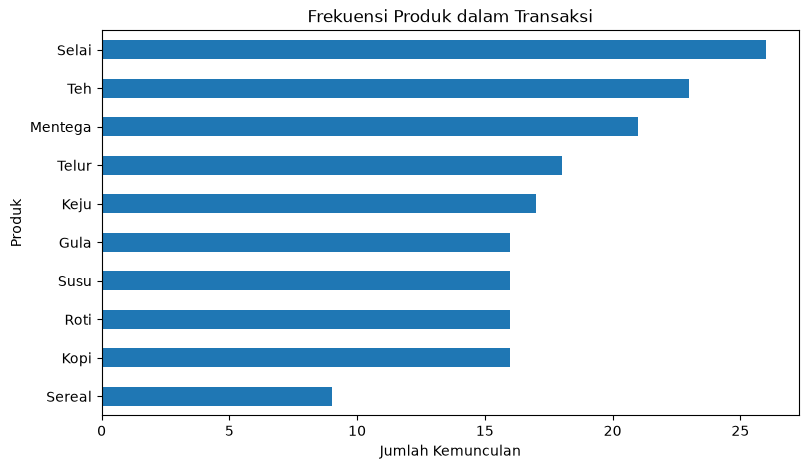

In [3]:
np.random.seed(42)

produk = [
    'Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
    'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'
]

# Buat 50 transaksi, setiap transaksi berisi 2-5 produk
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(
        list(np.random.choice(produk, n_item, replace=False))
    )

# Suntikkan pola tersembunyi: Roti sering bersama Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:")
for i, t in enumerate(transaksi[:5], start=1):
    print(f"Transaksi {i}: {t}")

print("\nJumlah transaksi:", len(transaksi))

# Frekuensi setiap produk
frekuensi_produk = pd.Series(
    [item for t in transaksi for item in t]
).value_counts()

print("\nFrekuensi produk:")
display(frekuensi_produk.to_frame("frekuensi"))

plt.figure(figsize=(9, 5))
frekuensi_produk.sort_values(ascending=True).plot(kind="barh")
plt.title("Frekuensi Produk dalam Transaksi")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Produk")
plt.show()

## Langkah 3 — One-Hot Encoding Transaksi

Data transaksi berbentuk daftar produk diubah menjadi tabel biner. Nilai **True/1** menunjukkan produk terdapat dalam transaksi, sedangkan **False/0** menunjukkan produk tidak terdapat dalam transaksi.

In [4]:
te = TransactionEncoder()

te_array = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("Shape:", df.shape)
display(df.head())

Shape: (50, 10)


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


## Langkah 4 — Frequent Itemset dengan Apriori

Algoritma Apriori digunakan untuk mencari kombinasi produk yang sering muncul bersama. Beberapa nilai `min_support` dibandingkan untuk melihat pengaruhnya terhadap jumlah itemset yang ditemukan.

In [5]:
hasil_support = []

for ms in [0.05, 0.10, 0.20]:
    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )
    hasil_support.append({
        "min_support": ms,
        "jumlah_itemset": len(freq)
    })
    print(
        f"min_support={ms}: "
        f"{len(freq)} itemset ditemukan"
    )

display(pd.DataFrame(hasil_support))

# Gunakan min_support yang menghasilkan jumlah itemset wajar
freq_items = apriori(
    df,
    min_support=0.10,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    "support",
    ascending=False
).reset_index(drop=True)

print("\nFrequent itemset:")
display(freq_items.head(15))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan


,min_support,jumlah_itemset
0,0.05,74
1,0.10,44
2,0.20,13



Frequent itemset:


,support,itemsets
0,0.52,frozenset({Selai})
1,0.46,frozenset({Teh})
2,0.42,frozenset({Mentega})
3,0.36,frozenset({Telur})
4,0.34,frozenset({Keju})
5,0.32,frozenset({Gula})
6,0.32,frozenset({Kopi})
7,0.32,frozenset({Roti})
8,0.32,frozenset({Susu})
9,0.24,"frozenset({Selai, Teh})"


### Interpretasi Frequent Itemset

`Support` menunjukkan proporsi transaksi yang mengandung item atau kombinasi item tertentu. Semakin besar nilai support, semakin sering kombinasi tersebut muncul dalam dataset.

## Langkah 5 — Membentuk & Menyaring Aturan Asosiasi

Aturan asosiasi dibentuk menggunakan `association_rules`. Aturan kemudian disaring berdasarkan **confidence** dan **lift**, lalu diurutkan berdasarkan nilai lift tertinggi.

- **Support:** seberapa sering kombinasi muncul.
- **Confidence:** kemungkinan consequent muncul ketika antecedent muncul.
- **Lift:** kekuatan hubungan dibandingkan kemunculan secara independen.
- **Lift > 1:** menunjukkan hubungan positif.

In [6]:
rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[
    rules["lift"] > 1
].sort_values(
    "lift",
    ascending=False
).reset_index(drop=True)

print("Jumlah aturan setelah filtering:", len(rules))

if len(rules) > 0:
    hasil_rules = rules[
        ["antecedents", "consequents",
         "support", "confidence", "lift"]
    ].head(10).copy()

    hasil_rules["antecedents"] = hasil_rules["antecedents"].apply(
        lambda x: ", ".join(sorted(x))
    )
    hasil_rules["consequents"] = hasil_rules["consequents"].apply(
        lambda x: ", ".join(sorted(x))
    )

    display(hasil_rules)
else:
    print("Tidak ada aturan yang memenuhi filter.")
    print("Jika diperlukan, turunkan min_threshold confidence.")

Jumlah aturan setelah filtering: 16


,antecedents,consequents,support,confidence,lift
0,"Keju, Teh",Telur,0.12,0.857143,2.380952
1,"Mentega, Selai",Kopi,0.10,0.625000,1.953125
2,"Gula, Roti",Selai,0.10,1.000000,1.923077
3,Sereal,Mentega,0.14,0.777778,1.851852
4,"Teh, Telur",Keju,0.12,0.600000,1.764706
5,"Kopi, Selai",Mentega,0.10,0.714286,1.700680
6,"Keju, Telur",Teh,0.12,0.750000,1.630435
7,"Gula, Selai",Roti,0.10,0.500000,1.562500
8,"Kopi, Mentega",Selai,0.10,0.714286,1.373626
9,Roti,Selai,0.22,0.687500,1.322115


### Interpretasi Aturan Asosiasi

Aturan dengan **lift paling tinggi** menunjukkan pasangan atau kombinasi produk yang memiliki hubungan paling kuat dibandingkan kemunculannya secara independen. Aturan seperti `Roti → Selai` dapat menjadi contoh rekomendasi bisnis, misalnya menempatkan produk yang berkaitan secara berdekatan atau memberikan promosi bundling.

## Langkah 6 — Rekomender Sederhana dengan Content-Based Filtering

Selanjutnya dibuat katalog produk sederhana berdasarkan kategori. Kemiripan antarproduk dihitung menggunakan **cosine similarity** pada representasi one-hot kategori.

In [7]:
kategori_produk = [
    'Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
    'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'
]

katalog = pd.DataFrame({
    "produk": produk,
    "kategori": kategori_produk
})

print("Katalog produk:")
display(katalog)

fitur = pd.get_dummies(katalog["kategori"])

sim_matrix = cosine_similarity(fitur)

sim_df = pd.DataFrame(
    sim_matrix,
    index=katalog["produk"],
    columns=katalog["produk"]
)

print("\nMatriks cosine similarity:")
display(sim_df.round(2))

Katalog produk:


,produk,kategori
0,Roti,Bakery
1,Selai,Bakery
2,Susu,Dairy
3,Sereal,Bakery
4,Telur,Dairy
5,Keju,Dairy
6,Kopi,Minuman
7,Gula,Bumbu
8,Teh,Minuman
9,Mentega,Dairy



Matriks cosine similarity:


produk,Roti,Selai,Susu,Sereal,Telur,Keju,Kopi,Gula,Teh,Mentega
produk,,,,,,,,,,
Roti,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Selai,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Susu,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Sereal,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Telur,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Keju,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Kopi,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
Gula,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Teh,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [8]:
def rekomendasi_serupa(nama_produk, top_n=3):
    if nama_produk not in katalog["produk"].values:
        return []

    idx = katalog.index[
        katalog["produk"] == nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))

    # Urutkan dari similarity terbesar
    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )

    # Hilangkan produk target sendiri
    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    return katalog.iloc[
        [i for i, _ in skor]
    ]["produk"].tolist()


print(
    "Mirip dengan Roti:",
    rekomendasi_serupa("Roti")
)

print(
    "Mirip dengan Susu:",
    rekomendasi_serupa("Susu")
)

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu: ['Telur', 'Keju', 'Mentega']


## Langkah 7 — Membandingkan Kedua Pendekatan

Association Rules memberikan rekomendasi berdasarkan **pola pembelian bersama**. Content-Based Filtering memberikan rekomendasi berdasarkan **kemiripan karakteristik/kategori produk**.

Kedua pendekatan dapat memberikan hasil berbeda karena dasar perhitungannya berbeda. Dalam sistem nyata, keduanya dapat digabungkan menjadi pendekatan **hybrid recommender system**.

In [9]:
produk_target = "Roti"

print("=== Rekomendasi Association Rules ===")

if len(rules) > 0:
    rules_terkait = rules[
        rules["antecedents"].apply(
            lambda x: produk_target in x
        )
    ]

    if len(rules_terkait) > 0:
        tampil_rules = rules_terkait[
            ["antecedents", "consequents",
             "support", "confidence", "lift"]
        ].head(10).copy()

        tampil_rules["antecedents"] = tampil_rules[
            "antecedents"
        ].apply(lambda x: ", ".join(sorted(x)))

        tampil_rules["consequents"] = tampil_rules[
            "consequents"
        ].apply(lambda x: ", ".join(sorted(x)))

        display(tampil_rules)
    else:
        print("Belum ditemukan aturan dengan Roti sebagai antecedent.")
else:
    print("Tidak ada association rule yang tersedia.")

print("\n=== Rekomendasi Content-Based ===")
print(
    rekomendasi_serupa(
        produk_target,
        top_n=3
    )
)

=== Rekomendasi Association Rules ===


,antecedents,consequents,support,confidence,lift
2,"Gula, Roti",Selai,0.10,1.0000,1.923077
9,Roti,Selai,0.22,0.6875,1.322115



=== Rekomendasi Content-Based ===
['Selai', 'Sereal', 'Susu']


## Analisis & Pembahasan

**Association Rule Mining** cocok digunakan ketika tersedia data transaksi dan ingin mengetahui produk apa yang cenderung dibeli secara bersamaan. Informasi confidence dan lift dapat digunakan untuk membantu strategi cross-selling dan bundling.

**Content-Based Filtering** cocok ketika informasi karakteristik produk tersedia. Produk yang mempunyai kategori yang sama akan memiliki nilai kemiripan yang tinggi.

Pada dataset praktikum ini, pola transaksi dibuat secara sintetis sehingga hasil aturan asosiasi dipengaruhi oleh pola yang sengaja dimasukkan. Pada data nyata, hasil aturan perlu diuji kembali berdasarkan jumlah transaksi, periode data, dan konteks bisnis.

## Kesimpulan

Berdasarkan praktikum, algoritma Apriori berhasil digunakan untuk menemukan frequent itemset dari data transaksi. Association Rules kemudian digunakan untuk mengetahui hubungan antarproduk melalui support, confidence, dan lift. Nilai lift lebih dari 1 menunjukkan adanya hubungan positif antarproduk.

Selain itu, content-based filtering dengan cosine similarity dapat digunakan untuk memberikan rekomendasi produk berdasarkan kesamaan kategori. Association Rules dan Content-Based Filtering memiliki pendekatan yang berbeda sehingga dapat digunakan secara bersama-sama untuk membangun sistem rekomendasi yang lebih baik.